In [1]:
import numpy as np

# ── Memory estimation for each box configuration ──
CONFIGS = [
    # {"label": "300 Mpc",  "BOX_LEN": 300,  "DIM": 256,  "HII_DIM": 128},
    # {"label": "500 Mpc",  "BOX_LEN": 500,  "DIM": 400,  "HII_DIM": 200},
    {"label": "500 Mpc",  "BOX_LEN": 500,  "DIM": 600,  "HII_DIM": 300},
    {"label": "1000 Mpc", "BOX_LEN": 1000, "DIM": 800,  "HII_DIM": 400},
    # {"label": "1250 Mpc", "BOX_LEN": 1200, "DIM": 1200, "HII_DIM": 600},
]

Z_MIN, Z_MAX = 6.0, 12.0
# Comoving distance z=6 to z=12 (Planck18)
D_LOS_MPC = 4100  # approximate comoving distance span

print(f"{'Config':<12} {'DIM³ (GB)':>10} {'HII³ (GB)':>10} {'N_tiles':>8} {'LC buffer (GB)':>14} {'Est. total (GB)':>16}")
print("-" * 80)

for c in CONFIGS:
    dim3_gb = c["DIM"]**3 * 4 / 1e9
    hii3_gb = c["HII_DIM"]**3 * 4 / 1e9
    n_tiles = D_LOS_MPC / c["BOX_LEN"]
    # Lightcone LOS: N_slices ≈ D_LOS / cell_size = D_LOS / (BOX_LEN/HII_DIM)
    cell_size = c["BOX_LEN"] / c["HII_DIM"]
    n_slices = int(D_LOS_MPC / cell_size)
    lc_buf_gb = c["HII_DIM"]**2 * n_slices * 4 * 3 / 1e9  # 3 fields
    # Total estimate: ~5× DIM³ (C internals) + lightcone buffer + overhead
    total_est = 5 * dim3_gb + lc_buf_gb + 2.0  # +2 GB baseline overhead
    
    print(f"{c['label']:<12} {dim3_gb:>10.2f} {hii3_gb:>10.2f} {n_tiles:>8.1f} {lc_buf_gb:>14.2f} {total_est:>16.1f}")

print("\n>>> Check your node's available RAM before choosing which CONFIGS to run.")
print(">>> On a GPU node with 64 GB, CONFIGS up to 750 Mpc should be safe.")
print(">>> 1000 Mpc needs ~25 GB peak — fine on 64 GB nodes.")
print(">>> 1500 Mpc needs ~40+ GB — use a high-memory node.")


Config        DIM³ (GB)  HII³ (GB)  N_tiles LC buffer (GB)  Est. total (GB)
--------------------------------------------------------------------------------
500 Mpc            0.86       0.11      8.2           2.66              9.0
1000 Mpc           2.05       0.26      4.1           3.15             15.4

>>> Check your node's available RAM before choosing which CONFIGS to run.
>>> On a GPU node with 64 GB, CONFIGS up to 750 Mpc should be safe.
>>> 1000 Mpc needs ~25 GB peak — fine on 64 GB nodes.
>>> 1500 Mpc needs ~40+ GB — use a high-memory node.


In [2]:
# ── Check available memory on this node ──
import os
try:
    import psutil
    mem = psutil.virtual_memory()
    print(f"Total RAM: {mem.total / 1e9:.1f} GB")
    print(f"Available:  {mem.available / 1e9:.1f} GB")
except ImportError:
    # Fallback for systems without psutil
    with open('/proc/meminfo') as f:
        for line in f:
            if 'MemTotal' in line or 'MemAvailable' in line:
                print(line.strip())

Total RAM: 810.2 GB
Available:  616.0 GB


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from astropy import units as un
import gc
import time
import warnings

# Patch for matplotlib >= 3.9 compatibility with 21cmFAST
import matplotlib
if not hasattr(plt, 'register_cmap'):
    plt.register_cmap = matplotlib.colormaps.register

import py21cmfast as p21c
print(f"21cmFAST version: {p21c.__version__}")

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

21cmFAST version: 3.4.0


In [4]:
# ── Detect API version ──
# v4.0+: InputParameters, SimulationOptions
# v3.4.0: UserParams + RectilinearLightconer (transitional)
# v3.3.x: UserParams only (no RectilinearLightconer)

HAS_V4 = hasattr(p21c, 'InputParameters')
HAS_LIGHTCONER = hasattr(p21c, 'RectilinearLightconer')

if HAS_V4:
    print("API: v4+ (InputParameters + RectilinearLightconer)")
elif HAS_LIGHTCONER:
    print("API: v3.4+ (UserParams + RectilinearLightconer)")
else:
    print("API: v3.3 or older (UserParams only)")
    print("WARNING: RectilinearLightconer not available.")
    print("         Lightcone sections will use the legacy run_lightcone() API.")
    print("         Consider upgrading to 21cmFAST >= 3.4.0")

# Check for CacheConfig (v3.4+ for disabling caching)
try:
    from py21cmfast.cache_tools import CacheConfig
    HAS_CACHECONFIG = True
    print(f"CacheConfig: available (from cache_tools)")
except ImportError:
    try:
        from py21cmfast.io.caching import CacheConfig
        HAS_CACHECONFIG = True
        print(f"CacheConfig: available (from io.caching)")
    except ImportError:
        HAS_CACHECONFIG = False
        print("CacheConfig: not available (will use default caching)")

API: v3.4+ (UserParams + RectilinearLightconer)
CacheConfig: not available (will use default caching)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from astropy import units as un
import gc
import time

# Patch for matplotlib >= 3.9 compatibility with 21cmFAST
import matplotlib
if not hasattr(plt, 'register_cmap'):
    plt.register_cmap = matplotlib.colormaps.register

import py21cmfast as p21c
print(f"21cmFAST version: {p21c.__version__}")

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

21cmFAST version: 3.4.0


In [6]:
# ── Physical constants ──
_SIGMA_T   = 6.6524587158e-25   # Thomson cross-section [cm²]
_C_CM_S    = 2.99792458e10      # speed of light [cm/s]
_T_CMB     = 2.725e6            # CMB temperature [µK]
_M_P       = 1.6726219e-24      # proton mass [g]
_MPC_TO_CM = 3.085677581e24     # Mpc → cm

# Cosmology (Planck 2018)
H0 = 67.36
h_cosmo = H0 / 100.0
OMEGA_M = 0.3153
OMEGA_B = 0.0493
OMEGA_L = 1.0 - OMEGA_M


def compute_ksz_coeval(vz, xHI, density, z, box_len, n_cells,
                        h=h_cosmo, omega_b=OMEGA_B):
    """Compute kSZ map from a single coeval box by summing along axis=2.
    
    This is the clean, no-tiling ground truth for non-Gaussianity.
    """
    Y_He = 0.24
    rho_crit_0 = 1.8788e-29 * h**2
    n_e_0 = rho_crit_0 * omega_b / _M_P * (1.0 + (1.0 - Y_He)) / 2.0
    n_e_z = n_e_0 * (1.0 + z)**3
    dl_cm = (box_len / (1.0 + z)) / n_cells * _MPC_TO_CM
    pref = -_T_CMB * _SIGMA_T * n_e_z * dl_cm
    
    x_e = 1.0 - np.clip(xHI, 0.0, 1.0)
    delta = density if density.mean() < 0.5 else density / density.mean() - 1.0
    
    # 21cmFAST velocity: comoving peculiar in Mpc/s → physical km/s → v/c
    a = 1.0 / (1.0 + z)
    v_over_c = a * vz * _MPC_TO_CM / _C_CM_S
    
    integrand = x_e * (1.0 + delta) * v_over_c
    return (pref * np.sum(integrand, axis=2)).astype(np.float32)


def compute_ksz_lightcone(velocity_z, xHI, density, redshifts, box_len):
    """Compute kSZ from a lightcone by summing along axis=2 with per-slice weighting.
    
    This is the simple method (no exp(-τ) damping) matching the coeval projection
    but applied to the full lightcone volume. Good enough for the convergence test
    since we're comparing the SAME method at different box sizes.
    """
    n_x, n_y, n_z = density.shape
    ksz_map = np.zeros((n_x, n_y), dtype=np.float64)
    
    Y_He = 0.24
    rho_crit_0 = 1.8788e-29 * h_cosmo**2
    n_e_0 = rho_crit_0 * OMEGA_B / _M_P * (1.0 + (1.0 - Y_He)) / 2.0
    
    for iz in range(n_z):
        z = redshifts[iz]
        a = 1.0 / (1.0 + z)
        n_e_z = n_e_0 * (1.0 + z)**3
        dl_cm = (box_len / (1.0 + z)) / n_z * _MPC_TO_CM
        pref = -_T_CMB * _SIGMA_T * n_e_z * dl_cm
        
        x_e = 1.0 - np.clip(xHI[:, :, iz], 0.0, 1.0)
        d = density[:, :, iz]
        delta = d if d.mean() < 0.5 else d / d.mean() - 1.0
        v_over_c = a * velocity_z[:, :, iz] * _MPC_TO_CM / _C_CM_S
        
        ksz_map += pref * x_e * (1.0 + delta) * v_over_c
    
    return ksz_map.astype(np.float32)


def pixel_stats(ksz_map):
    """Compute pixel-level non-Gaussianity statistics."""
    flat = (ksz_map - ksz_map.mean()).ravel().astype(np.float64)
    return {
        'std': flat.std(),
        'skewness': stats.skew(flat),
        'kurtosis': stats.kurtosis(flat),  # excess kurtosis
    }


print("Functions defined.")

Functions defined.


In [7]:
# ── Box configurations to test ──
# Resolution kept roughly constant: cell_size ~ 2.5 Mpc (HII grid).
# Comment out configs that exceed your node's memory.
CONFIGS = [
    # {"BOX_LEN": 300,  "DIM": 256,  "HII_DIM": 128},
    # {"BOX_LEN": 500,  "DIM": 400,  "HII_DIM": 200},
    {"BOX_LEN": 750,  "DIM": 600,  "HII_DIM": 300},
    {"BOX_LEN": 1000, "DIM": 800,  "HII_DIM": 400},   # ~15 GB
    # {"BOX_LEN": 1250, "DIM": 1100, "HII_DIM": 550}, # ~40 GB
]

SEED = 42
Z_EOR_MIN = 6.0
Z_EOR_MAX = 12.0
Z_COEVAL = 8.0  # reference coeval redshift (peak EoR)

print(f"Will test {len(CONFIGS)} box sizes.")
for c in CONFIGS:
    n_tiles = 4100 / c["BOX_LEN"]
    print(f"  BOX_LEN={c['BOX_LEN']} Mpc, DIM={c['DIM']}, HII_DIM={c['HII_DIM']}  "
          f"-> ~{n_tiles:.1f} tiles, cell={c['BOX_LEN']/c['HII_DIM']:.1f} Mpc")


Will test 2 box sizes.
  BOX_LEN=750 Mpc, DIM=600, HII_DIM=300  -> ~5.5 tiles, cell=2.5 Mpc
  BOX_LEN=1000 Mpc, DIM=800, HII_DIM=400  -> ~4.1 tiles, cell=2.5 Mpc


In [8]:
coeval_results = {}

def _get_coeval_fields(coeval):
    """Extract xHI, density, vz from a Coeval object, handling v3/v4 field names."""
    # Neutral fraction: v4 = neutral_fraction, v3 = xH_box
    if hasattr(coeval, 'neutral_fraction'):
        xHI = coeval.neutral_fraction
    elif hasattr(coeval, 'xH_box'):
        xHI = coeval.xH_box
    else:
        raise AttributeError("Cannot find neutral fraction field on Coeval object")
    
    # Density
    density = coeval.density
    
    # Velocity: v4 = velocity_z, v3.4 = velocity_z, v3.3 = velocity
    if hasattr(coeval, 'velocity_z'):
        vz = coeval.velocity_z
    elif hasattr(coeval, 'velocity'):
        vz = coeval.velocity
    else:
        raise AttributeError("Cannot find velocity field on Coeval object")
    
    return xHI, density, vz


for cfg in CONFIGS:
    box_len = cfg["BOX_LEN"]
    dim = cfg["DIM"]
    hii_dim = cfg["HII_DIM"]
    label = f"{box_len} Mpc"
    print(f"\n{'='*60}")
    print(f"Coeval z={Z_COEVAL}: BOX_LEN={box_len}, DIM={dim}, HII_DIM={hii_dim}")
    print(f"{'='*60}")
    
    t0 = time.time()
    
    if HAS_V4:
        # v4 API
        inputs = p21c.InputParameters(
            simulation_options=p21c.SimulationOptions(
                BOX_LEN=box_len, DIM=dim, HII_DIM=hii_dim,
            ),
            random_seed=SEED,
        )
        coeval = p21c.run_coeval(inputs=inputs, out_redshifts=[Z_COEVAL])[0]
    else:
        # v3.4 / v3.3 API
        user_params = p21c.UserParams(BOX_LEN=box_len, DIM=dim, HII_DIM=hii_dim)
        coeval = p21c.run_coeval(
            redshift=Z_COEVAL,
            user_params=user_params,
            random_seed=SEED,
            write = False,
        )
    
    xHI, density, vz = _get_coeval_fields(coeval)
    
    n_cells = xHI.shape[0]
    mean_xHI = float(xHI.mean())
    print(f"  <xHI> = {mean_xHI:.3f}")
    
    ksz_map = compute_ksz_coeval(vz, xHI, density, Z_COEVAL, box_len, n_cells)
    st = pixel_stats(ksz_map)
    
    coeval_results[label] = {
        'box_len': box_len, 'mean_xHI': mean_xHI,
        'std': st['std'], 'skewness': st['skewness'], 'kurtosis': st['kurtosis'],
        'ksz_map': ksz_map,
        'time': time.time() - t0,
    }
    
    print(f"  std={st['std']:.4e} µK, skew={st['skewness']:.4f}, kurt={st['kurtosis']:.4f}")
    print(f"  Time: {time.time() - t0:.1f} s")
    
    del coeval, xHI, density, vz, ksz_map
    gc.collect()

print("\nCoeval reference runs complete.")


Coeval z=8.0: BOX_LEN=750, DIM=600, HII_DIM=300


/home4/p314235/.conda/envs/21cmfast_env/lib/python3.11/site-packages/py21cmfast/inputs.py:515: UserWarning: The USE_INTERPOLATION_TABLES setting has changed in v3.1.2 to be default True. You can likely ignore this warning, but if you relied onhaving USE_INTERPOLATION_TABLES=False by *default*, please set it explicitly. To silence this warning, set it explicitly to True. Thiswarning will be removed in v4.
  warnings.warn(


2026-04-15 18:13:00 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:205 [pid=451149/thr=0] | Finished initialization.
2026-04-15 18:13:00 | DEBUG   | ps.c            | TFset_parameters:481 [pid=451149/thr=0] | Setting Transfer Function parameters.
2026-04-15 18:13:00 | DEBUG   | ps.c            | init_ps:636 [pid=451149/thr=0] | Initializing Power Spectrum with lower_limit=8.457500e-101, upper_limit=2.960125e+01, rel_tol=1.000000e-06, radius_8=11.8238
2026-04-15 18:13:00 | DEBUG   | ps.c            | init_ps:656 [pid=451149/thr=0] | Initialized Power Spectrum.
2026-04-15 18:13:41 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:255 [pid=451149/thr=0] | Drawn random fields.
2026-04-15 18:13:43 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:265 [pid=451149/thr=0] | FFT'd hires boxes.
2026-04-15 18:13:50 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:401 [pid=451149/thr=0] | Completed Relative velocities.
2026-04-15 18:14:11 | DEBUG   | GenerateICs.c   | Compu

  <xHI> = 0.584
  std=1.9290e+00 µK, skew=-0.0755, kurt=0.5205
  Time: 161.3 s

Coeval z=8.0: BOX_LEN=1000, DIM=800, HII_DIM=400


2026-04-15 18:15:42 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:205 [pid=451149/thr=0] | Finished initialization.
2026-04-15 18:15:42 | DEBUG   | ps.c            | TFset_parameters:481 [pid=451149/thr=0] | Setting Transfer Function parameters.
2026-04-15 18:15:42 | DEBUG   | ps.c            | init_ps:636 [pid=451149/thr=0] | Initializing Power Spectrum with lower_limit=8.457500e-101, upper_limit=2.960125e+01, rel_tol=1.000000e-06, radius_8=11.8238
2026-04-15 18:15:42 | DEBUG   | ps.c            | init_ps:656 [pid=451149/thr=0] | Initialized Power Spectrum.
2026-04-15 18:17:18 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:255 [pid=451149/thr=0] | Drawn random fields.
2026-04-15 18:17:24 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:265 [pid=451149/thr=0] | FFT'd hires boxes.
2026-04-15 18:17:40 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:401 [pid=451149/thr=0] | Completed Relative velocities.
2026-04-15 18:18:29 | DEBUG   | GenerateICs.c   | Compu

  <xHI> = 0.584
  std=2.3045e+00 µK, skew=0.0431, kurt=0.3419
  Time: 378.5 s

Coeval reference runs complete.


In [9]:
lightcone_results = {}

# Field names: v4 uses "neutral_fraction"/"velocity_z", v3 uses "xH_box"/"velocity"
if HAS_V4:
    LC_FIELDS = ("neutral_fraction", "density", "velocity_z")
    XHI_KEY, VZ_KEY = "neutral_fraction", "velocity_z"
else:
    LC_FIELDS = ("xH_box", "density", "velocity")
    XHI_KEY, VZ_KEY = "xH_box", "velocity"

print(f"Lightcone field names: {LC_FIELDS}")


def _run_lightcone_v4(cfg, seed):
    """v4: InputParameters + RectilinearLightconer.between_redshifts."""
    from py21cmfast.wrapper.inputs import get_logspaced_redshifts
    from py21cmfast.io.caching import CacheConfig as CC

    box_len, dim, hii_dim = cfg["BOX_LEN"], cfg["DIM"], cfg["HII_DIM"]
    resolution = box_len / hii_dim * un.Mpc
    node_redshifts = get_logspaced_redshifts(
        min_redshift=Z_EOR_MIN, max_redshift=Z_EOR_MAX + 2, z_step_factor=1.08,
    )
    inputs = p21c.InputParameters(
        simulation_options=p21c.SimulationOptions(BOX_LEN=box_len, DIM=dim, HII_DIM=hii_dim),
        random_seed=seed, node_redshifts=node_redshifts,
    )
    lightconer = p21c.RectilinearLightconer.between_redshifts(
        min_redshift=Z_EOR_MIN, max_redshift=Z_EOR_MAX,
        resolution=resolution, quantities=LC_FIELDS,
    )
    return p21c.run_lightcone(lightconer=lightconer, inputs=inputs, write=CC.off())


def _run_lightcone_legacy(cfg, seed):
    """v3.3 / v3.4: legacy run_lightcone(redshift, max_redshift, ...)."""
    box_len, dim, hii_dim = cfg["BOX_LEN"], cfg["DIM"], cfg["HII_DIM"]
    user_params = p21c.UserParams(BOX_LEN=box_len, DIM=dim, HII_DIM=hii_dim)
    return p21c.run_lightcone(
        redshift=Z_EOR_MIN, max_redshift=Z_EOR_MAX,
        user_params=user_params, random_seed=seed,
        lightcone_quantities=LC_FIELDS, write=False,
    )


def _extract_lc_fields(lc):
    """Extract arrays from lightcone, handling v3/v4 data access."""
    if hasattr(lc, "lightcones") and isinstance(lc.lightcones, dict):
        data = lc.lightcones
        xHI = next((data[k] for k in (XHI_KEY, "neutral_fraction", "xH_box") if k in data), None)
        density = data["density"]
        vz = next((data[k] for k in (VZ_KEY, "velocity_z", "velocity") if k in data), None)
        if xHI is None or vz is None:
            raise KeyError(f"Missing fields. Available: {list(data.keys())}")
    else:
        xHI = getattr(lc, "xH_box", getattr(lc, "neutral_fraction", None))
        density = lc.density
        vz = getattr(lc, "velocity", getattr(lc, "velocity_z", None))
        if xHI is None or vz is None:
            raise AttributeError("Cannot find xHI or velocity on lightcone")
    return vz, xHI, density, lc.lightcone_redshifts


# ── Main loop ──
for cfg in CONFIGS:
    box_len = cfg["BOX_LEN"]
    label = f"{box_len} Mpc"
    n_tiles_est = 4100 / box_len

    print(f"\n{'='*60}")
    print(f"Lightcone z={Z_EOR_MIN}-{Z_EOR_MAX}: BOX_LEN={box_len}")
    print(f"  Est. N_tiles = {n_tiles_est:.1f}")
    print(f"{'='*60}")

    t0 = time.time()
    try:
        if HAS_V4 and HAS_LIGHTCONER_FULL:
            print("  Using v4 API (RectilinearLightconer.between_redshifts)...")
            lc = _run_lightcone_v4(cfg, SEED)
        else:
            print("  Using legacy API (run_lightcone with redshift/max_redshift)...")
            lc = _run_lightcone_legacy(cfg, SEED)

        vz, xHI, density, redshifts = _extract_lc_fields(lc)
        print(f"  Shape: {density.shape}")
        print(f"  z range: {redshifts.min():.2f} - {redshifts.max():.2f}")

        ksz_lc = compute_ksz_lightcone(vz, xHI, density, redshifts, box_len)
        st = pixel_stats(ksz_lc)

        lightcone_results[label] = {
            "box_len": box_len, "n_tiles": n_tiles_est,
            "std": st["std"], "skewness": st["skewness"], "kurtosis": st["kurtosis"],
            "ksz_map": ksz_lc, "time": time.time() - t0,
        }
        print(f"  std={st['std']:.4e} uK, skew={st['skewness']:.4f}, kurt={st['kurtosis']:.4f}")
        print(f"  Time: {time.time() - t0:.1f} s")

        del lc, vz, xHI, density, redshifts, ksz_lc
        gc.collect()

    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()
        print(f"  Skipping BOX_LEN={box_len}.")
        gc.collect()
        continue

print(f"\nLightcone runs complete. Successful: {len(lightcone_results)}/{len(CONFIGS)}")


Lightcone field names: ('xH_box', 'density', 'velocity')

Lightcone z=6.0-12.0: BOX_LEN=750
  Est. N_tiles = 5.5
  Using legacy API (run_lightcone with redshift/max_redshift)...


2026-04-15 18:22:02 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:205 [pid=451149/thr=0] | Finished initialization.
2026-04-15 18:22:02 | DEBUG   | ps.c            | TFset_parameters:481 [pid=451149/thr=0] | Setting Transfer Function parameters.
2026-04-15 18:22:02 | DEBUG   | ps.c            | init_ps:636 [pid=451149/thr=0] | Initializing Power Spectrum with lower_limit=8.457500e-101, upper_limit=2.960125e+01, rel_tol=1.000000e-06, radius_8=11.8238
2026-04-15 18:22:02 | DEBUG   | ps.c            | init_ps:656 [pid=451149/thr=0] | Initialized Power Spectrum.
2026-04-15 18:22:42 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:255 [pid=451149/thr=0] | Drawn random fields.
2026-04-15 18:22:45 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:265 [pid=451149/thr=0] | FFT'd hires boxes.
2026-04-15 18:22:52 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:401 [pid=451149/thr=0] | Completed Relative velocities.
2026-04-15 18:23:13 | DEBUG   | GenerateICs.c   | Compu

  Shape: (300, 300, 639)
  z range: 6.00 - 12.00
  std=1.5127e+00 uK, skew=-0.0390, kurt=0.7260
  Time: 2337.0 s

Lightcone z=6.0-12.0: BOX_LEN=1000
  Est. N_tiles = 4.1
  Using legacy API (run_lightcone with redshift/max_redshift)...


2026-04-15 19:00:59 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:205 [pid=451149/thr=0] | Finished initialization.
2026-04-15 19:00:59 | DEBUG   | ps.c            | TFset_parameters:481 [pid=451149/thr=0] | Setting Transfer Function parameters.
2026-04-15 19:00:59 | DEBUG   | ps.c            | init_ps:636 [pid=451149/thr=0] | Initializing Power Spectrum with lower_limit=8.457500e-101, upper_limit=2.960125e+01, rel_tol=1.000000e-06, radius_8=11.8238
2026-04-15 19:00:59 | DEBUG   | ps.c            | init_ps:656 [pid=451149/thr=0] | Initialized Power Spectrum.
2026-04-15 19:02:34 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:255 [pid=451149/thr=0] | Drawn random fields.
2026-04-15 19:02:40 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:265 [pid=451149/thr=0] | FFT'd hires boxes.
2026-04-15 19:02:57 | DEBUG   | GenerateICs.c   | ComputeInitialConditions:401 [pid=451149/thr=0] | Completed Relative velocities.
2026-04-15 19:03:45 | DEBUG   | GenerateICs.c   | Compu

NameError: name 'CONFIGS' is not defined

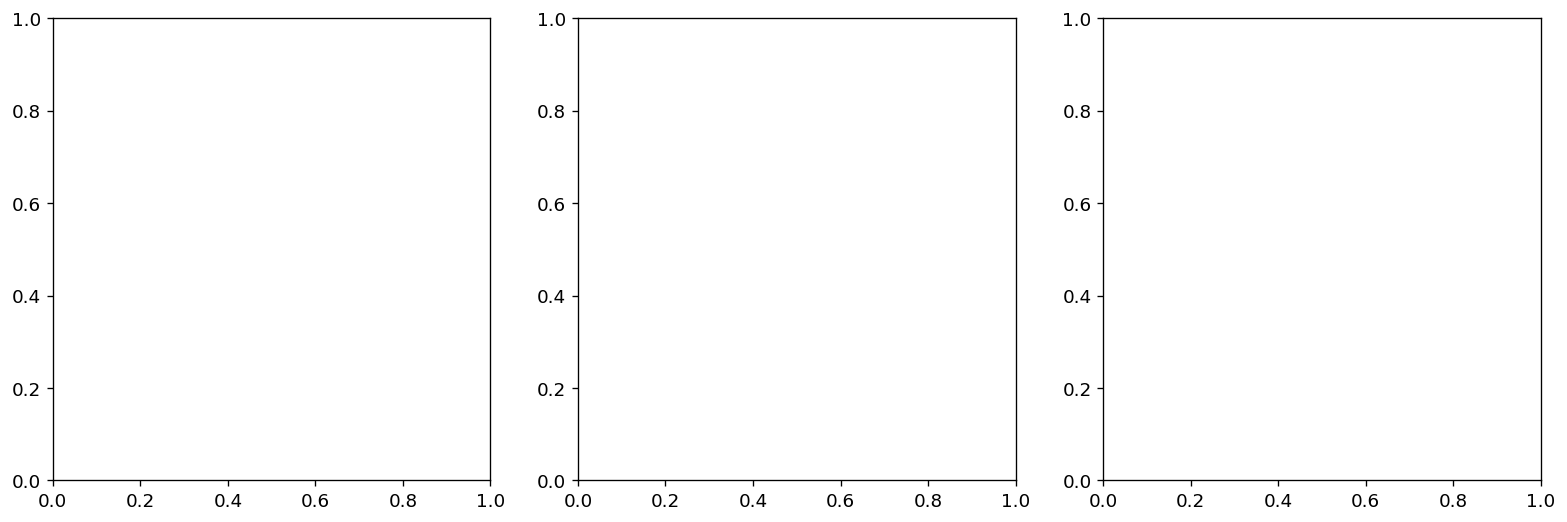

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

box_lens = [cfg['BOX_LEN'] for cfg in CONFIGS]

# ── Left: |Skewness| vs BOX_LEN ──
ax = axes[0]
coev_skew = [abs(coeval_results[f"{bl} Mpc"]['skewness']) for bl in box_lens
             if f"{bl} Mpc" in coeval_results]
coev_bl = [bl for bl in box_lens if f"{bl} Mpc" in coeval_results]
ax.plot(coev_bl, coev_skew, 's-', color='C0', ms=8, lw=2, label='Coeval (z=8)')

if lightcone_results:
    lc_skew = [abs(lightcone_results[f"{bl} Mpc"]['skewness']) for bl in box_lens
              if f"{bl} Mpc" in lightcone_results]
    lc_bl = [bl for bl in box_lens if f"{bl} Mpc" in lightcone_results]
    ax.plot(lc_bl, lc_skew, 'o-', color='C3', ms=8, lw=2, label='Lightcone (z=6–12)')
    
    # 1/sqrt(N_tiles) prediction scaled to smallest box
    if lc_skew:
        bl_pred = np.linspace(200, 1200, 50)
        n_tiles_pred = 4100 / bl_pred
        n_tiles_ref = 4100 / lc_bl[0]
        pred = lc_skew[0] * np.sqrt(n_tiles_ref / n_tiles_pred)
        ax.plot(bl_pred, pred, '--', color='grey', alpha=0.5,
                label=r'$\propto 1/\sqrt{N_{\rm tiles}}$')

ax.set_xlabel('BOX_LEN [Mpc]')
ax.set_ylabel('|Skewness|')
ax.set_title('Skewness convergence')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Centre: Excess kurtosis vs BOX_LEN ──
ax = axes[1]
coev_kurt = [coeval_results[f"{bl} Mpc"]['kurtosis'] for bl in box_lens
             if f"{bl} Mpc" in coeval_results]
ax.plot(coev_bl, coev_kurt, 's-', color='C0', ms=8, lw=2, label='Coeval (z=8)')

if lightcone_results:
    lc_kurt = [lightcone_results[f"{bl} Mpc"]['kurtosis'] for bl in box_lens
              if f"{bl} Mpc" in lightcone_results]
    ax.plot(lc_bl, lc_kurt, 'o-', color='C3', ms=8, lw=2, label='Lightcone (z=6–12)')

ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('BOX_LEN [Mpc]')
ax.set_ylabel('Excess kurtosis')
ax.set_title('Kurtosis convergence')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Right: σ(kSZ) vs BOX_LEN ──
ax = axes[2]
coev_std = [coeval_results[f"{bl} Mpc"]['std'] for bl in box_lens
            if f"{bl} Mpc" in coeval_results]
ax.plot(coev_bl, coev_std, 's-', color='C0', ms=8, lw=2, label='Coeval (z=8)')

if lightcone_results:
    lc_std = [lightcone_results[f"{bl} Mpc"]['std'] for bl in box_lens
             if f"{bl} Mpc" in lightcone_results]
    ax.plot(lc_bl, lc_std, 'o-', color='C3', ms=8, lw=2, label='Lightcone (z=6–12)')

ax.set_xlabel('BOX_LEN [Mpc]')
ax.set_ylabel(r'$\sigma_{\rm kSZ}$ [$\mu$K]')
ax.set_title('RMS convergence')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Lightcone kSZ: box-size convergence of non-Gaussianity', fontsize=13)
plt.tight_layout()
plt.savefig('boxsize_convergence.pdf', dpi=300, bbox_inches='tight')
plt.savefig('boxsize_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: boxsize_convergence.pdf")

In [ ]:
x_gauss = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, len(CONFIGS), figsize=(5 * len(CONFIGS), 5), sharey=True)
if len(CONFIGS) == 1:
    axes = [axes]

for ax, cfg in zip(axes, CONFIGS):
    bl = cfg['BOX_LEN']
    label = f"{bl} Mpc"
    
    # Coeval reference
    if label in coeval_results:
        m = coeval_results[label]['ksz_map']
        flat = (m - m.mean()) / m.std()
        ax.hist(flat.ravel(), bins=80, density=True, alpha=0.5, color='C0',
                histtype='stepfilled', label=f'Coeval (skew={coeval_results[label]["skewness"]:.3f})')
    
    # Lightcone
    if label in lightcone_results:
        m = lightcone_results[label]['ksz_map']
        flat = (m - m.mean()) / m.std()
        ax.hist(flat.ravel(), bins=80, density=True, alpha=0.5, color='C3',
                histtype='stepfilled', label=f'Lightcone (skew={lightcone_results[label]["skewness"]:.3f})')
    
    ax.plot(x_gauss, stats.norm.pdf(x_gauss), 'k--', lw=1.5, alpha=0.5, label='Gaussian')
    ax.set_xlabel(r'$\Delta T / \sigma$')
    ax.set_title(f'BOX_LEN = {bl} Mpc\n({4100/bl:.0f} tiles)', fontsize=10)
    ax.set_yscale('log')
    ax.set_ylim(1e-4, 2)
    ax.set_xlim(-5, 5)
    ax.legend(fontsize=7)

axes[0].set_ylabel('PDF')
plt.suptitle('Pixel PDF: coeval vs lightcone at different box sizes', fontsize=13)
plt.tight_layout()
plt.savefig('boxsize_pdf_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig('boxsize_pdf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

: 

In [ ]:
print(f"{'BOX_LEN':>8} {'N_tiles':>8} {'Coeval skew':>12} {'LC skew':>10} {'Ratio':>8} {'1/√N pred':>10}")
print("-" * 65)

for cfg in CONFIGS:
    bl = cfg['BOX_LEN']
    label = f"{bl} Mpc"
    n_t = 4100 / bl
    
    c_skew = coeval_results[label]['skewness'] if label in coeval_results else float('nan')
    l_skew = lightcone_results[label]['skewness'] if label in lightcone_results else float('nan')
    ratio = abs(l_skew / c_skew) if (c_skew != 0 and not np.isnan(l_skew)) else float('nan')
    pred = 1.0 / np.sqrt(n_t)
    
    print(f"{bl:>8} {n_t:>8.1f} {c_skew:>12.4f} {l_skew:>10.4f} {ratio:>8.3f} {pred:>10.3f}")

print("\nIf 'Ratio' tracks '1/√N pred', the tiling artifact is confirmed.")
print("If 'Ratio' is constant, the washout is physical (not an artifact).")

: 

In [ ]:
# ── Run short lightcones with brightness_temp for visualisation ──
# We use smaller DIM to save memory since we only need the image.

bt_lightcones = {}  # {label: {bt_slice, redshifts, ...}}

VIS_CONFIGS = [
    {"BOX_LEN": 300,  "DIM": 256, "HII_DIM": 128},
    {"BOX_LEN": 500,  "DIM": 400, "HII_DIM": 200},
    {"BOX_LEN": 750,  "DIM": 512, "HII_DIM": 256},
]

if HAS_V4:
    BT_FIELDS = ("brightness_temp",)
else:
    BT_FIELDS = ("brightness_temp",)

for cfg in VIS_CONFIGS:
    box_len = cfg["BOX_LEN"]
    label = f"{box_len} Mpc"
    print(f"\nBrightness temp lightcone: BOX_LEN={box_len}")
    
    t0 = time.time()
    try:
        if HAS_V4 and HAS_LIGHTCONER_FULL:
            from py21cmfast.wrapper.inputs import get_logspaced_redshifts
            from py21cmfast.io.caching import CacheConfig as CC
            resolution = box_len / cfg["HII_DIM"] * un.Mpc
            node_redshifts = get_logspaced_redshifts(
                min_redshift=Z_EOR_MIN, max_redshift=Z_EOR_MAX + 2, z_step_factor=1.08,
            )
            inputs = p21c.InputParameters(
                simulation_options=p21c.SimulationOptions(
                    BOX_LEN=box_len, DIM=cfg["DIM"], HII_DIM=cfg["HII_DIM"]),
                random_seed=SEED, node_redshifts=node_redshifts,
            )
            lightconer = p21c.RectilinearLightconer.between_redshifts(
                min_redshift=Z_EOR_MIN, max_redshift=Z_EOR_MAX,
                resolution=resolution, quantities=BT_FIELDS,
            )
            lc = p21c.run_lightcone(lightconer=lightconer, inputs=inputs, write=CC.off())
            bt = lc.lightcones["brightness_temp"]
            zs = lc.lightcone_redshifts
        else:
            user_params = p21c.UserParams(
                BOX_LEN=box_len, DIM=cfg["DIM"], HII_DIM=cfg["HII_DIM"])
            lc = p21c.run_lightcone(
                redshift=Z_EOR_MIN, max_redshift=Z_EOR_MAX,
                user_params=user_params, random_seed=SEED,
                write=False,
            )
            if hasattr(lc, 'lightcones') and isinstance(lc.lightcones, dict):
                bt = lc.lightcones["brightness_temp"]
            else:
                bt = lc.brightness_temp
            zs = lc.lightcone_redshifts
        
        ny = bt.shape[1]
        bt_slice = bt[:, ny // 2, :].copy()
        bt_los_mean = bt_slice.mean(axis=0).copy()
        
        bt_lightcones[label] = {
            "bt_slice": bt_slice,
            "bt_los_mean": bt_los_mean,
            "redshifts": zs.copy(),
            "box_len": box_len,
            "n_tiles": 4100 / box_len,
        }
        print(f"  Shape: {bt.shape}, Time: {time.time()-t0:.1f} s")
        
        del lc, bt
        gc.collect()
        
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()
        gc.collect()

print(f"\nBrightness temp lightcones: {len(bt_lightcones)}/{len(VIS_CONFIGS)} successful")

: 

In [ ]:
# ── Plot brightness temperature slices side by side ──
n_lc = len(bt_lightcones)
if n_lc == 0:
    print("No brightness temp lightcones to plot.")
else:
    fig, axes = plt.subplots(n_lc, 1, figsize=(14, 3.5 * n_lc), sharex=False)
    if n_lc == 1:
        axes = [axes]
    
    for ax, (label, data) in zip(axes, sorted(bt_lightcones.items(),
                                              key=lambda x: x[1]['box_len'])):
        bt_slice = data["bt_slice"]
        zs = data["redshifts"]
        box_len = data["box_len"]
        n_tiles = data["n_tiles"]
        
        extent = [zs.min(), zs.max(), 0, box_len]
        
        im = ax.imshow(bt_slice, aspect='auto', origin='lower',
                       extent=extent, cmap='EoR',
                       vmin=-150, vmax=30)
        
        # Mark tile boundaries with vertical lines
        from scipy.interpolate import interp1d
        try:
            from astropy.cosmology import Planck18
            d_los = Planck18.comoving_distance(zs).to('Mpc').value
        except ImportError:
            from scipy.integrate import cumulative_trapezoid
            _Hz = H0 * np.sqrt(OMEGA_M * (1 + zs)**3 + (1 - OMEGA_M))
            d_los = np.concatenate([[0], cumulative_trapezoid(C_KM_S / _Hz, zs)])
        
        d_min, d_max = d_los.min(), d_los.max()
        z_of_d = interp1d(d_los, zs, bounds_error=False, fill_value='extrapolate')
        
        tile_d = np.arange(d_min + box_len, d_max, box_len)
        tile_z = z_of_d(tile_d)
        for tz in tile_z:
            if zs.min() < tz < zs.max():
                ax.axvline(tz, color='white', ls='--', lw=0.6, alpha=0.5)
        
        ax.set_ylabel(f'Transverse [Mpc]')
        ax.set_title(f'BOX_LEN = {box_len} Mpc  (~{n_tiles:.0f} tiles)',
                     fontsize=11, fontweight='bold')
        
        cbar = fig.colorbar(im, ax=ax, pad=0.01, aspect=20)
        cbar.set_label(r'$\delta T_b$ [mK]', fontsize=9)
    
    axes[-1].set_xlabel(r'Redshift $z$')
    plt.suptitle('Brightness temperature lightcone slices — periodicity comparison',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('lightcone_bt_slices.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('lightcone_bt_slices.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: lightcone_bt_slices.pdf")

# ── Plot LOS-mean brightness temp to show periodicity directly ──
if bt_lightcones:
    fig, ax = plt.subplots(figsize=(12, 4))
    
    for label, data in sorted(bt_lightcones.items(), key=lambda x: x[1]['box_len']):
        zs = data["redshifts"]
        bt_mean = data["bt_los_mean"]
        box_len = data["box_len"]
        ax.plot(zs, bt_mean, lw=1.2,
                label=f'{box_len} Mpc (~{4100/box_len:.0f} tiles)', alpha=0.8)
    
    ax.set_xlabel(r'Redshift $z$')
    ax.set_ylabel(r'$\langle \delta T_b \rangle_x$ [mK]')
    ax.set_title('LOS-averaged brightness temperature — periodicity ripples')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig('lightcone_bt_los_mean.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('lightcone_bt_los_mean.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: lightcone_bt_los_mean.pdf")

: 

In [ ]:
# ── Plot brightness temp AND velocity slices side by side ──
# Left column: brightness_temp, Right column: velocity (LOS)
# Velocity shows the periodicity much more clearly.

n_lc = len(bt_lightcones)
if n_lc == 0:
    print("No lightcones to plot.")
else:
    sorted_data = sorted(bt_lightcones.items(), key=lambda x: x[1]["box_len"])
    
    fig, axes = plt.subplots(n_lc, 2, figsize=(16, 3.2 * n_lc),
                             sharex=False)
    if n_lc == 1:
        axes = axes.reshape(1, -1)
    
    # Comoving distance helper for tile boundaries
    from scipy.interpolate import interp1d
    _C_KM = 2.99792458e5
    _H0, _OM = 67.36, 0.3153
    
    def _tile_redshifts(zs, box_len):
        """Compute redshifts of tile boundaries."""
        try:
            from astropy.cosmology import Planck18
            d_los = Planck18.comoving_distance(zs).to("Mpc").value
        except ImportError:
            from scipy.integrate import cumulative_trapezoid
            _Hz = _H0 * np.sqrt(_OM * (1 + zs)**3 + (1 - _OM))
            d_los = np.concatenate([[0], cumulative_trapezoid(_C_KM / _Hz, zs)])
        z_of_d = interp1d(d_los, zs, bounds_error=False, fill_value="extrapolate")
        tile_d = np.arange(d_los.min() + box_len, d_los.max(), box_len)
        return z_of_d(tile_d)
    
    for row, (label, data) in enumerate(sorted_data):
        zs = data["redshifts"]
        box_len = data["box_len"]
        n_tiles = data["n_tiles"]
        tile_zs = _tile_redshifts(zs, box_len)
        extent = [zs.min(), zs.max(), 0, box_len]
        
        # Left: brightness temperature
        ax_bt = axes[row, 0]
        im_bt = ax_bt.imshow(data["bt_slice"], aspect="auto", origin="lower",
                             extent=extent, cmap="RdBu_r", vmin=-150, vmax=30)
        for tz in tile_zs:
            if zs.min() < tz < zs.max():
                ax_bt.axvline(tz, color="white", ls="--", lw=0.5, alpha=0.5)
        ax_bt.set_ylabel(f"Transverse [Mpc]")
        if row == 0:
            ax_bt.set_title(r"Brightness temperature $\delta T_b$", fontsize=11)
        ax_bt.text(0.02, 0.95, f"{box_len} Mpc (~{n_tiles:.0f} tiles)",
                   transform=ax_bt.transAxes, fontsize=9, va="top",
                   color="white", fontweight="bold",
                   bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))
        
        # Right: velocity (LOS)
        ax_vz = axes[row, 1]
        vz_slice = data["vz_slice"]
        vlim = np.percentile(np.abs(vz_slice), 99)
        im_vz = ax_vz.imshow(vz_slice, aspect="auto", origin="lower",
                             extent=extent, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
        for tz in tile_zs:
            if zs.min() < tz < zs.max():
                ax_vz.axvline(tz, color="black", ls="--", lw=0.5, alpha=0.5)
        ax_vz.set_ylabel("")
        ax_vz.set_yticklabels([])
        if row == 0:
            ax_vz.set_title(r"LOS velocity $v_z$", fontsize=11)
        ax_vz.text(0.02, 0.95, f"{box_len} Mpc (~{n_tiles:.0f} tiles)",
                   transform=ax_vz.transAxes, fontsize=9, va="top",
                   fontweight="bold",
                   bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))
        
        # Colorbars
        fig.colorbar(im_bt, ax=ax_bt, pad=0.01, aspect=20,
                     label=r"$\delta T_b$ [mK]" if row == n_lc - 1 else "")
        fig.colorbar(im_vz, ax=ax_vz, pad=0.01, aspect=20,
                     label=r"$v_z$ [Mpc/s]" if row == n_lc - 1 else "")
    
    axes[-1, 0].set_xlabel(r"Redshift $z$")
    axes[-1, 1].set_xlabel(r"Redshift $z$")
    plt.suptitle("Lightcone slices: brightness temperature (left) vs velocity (right)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("lightcone_bt_vz_slices.pdf", dpi=300, bbox_inches="tight")
    plt.savefig("lightcone_bt_vz_slices.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: lightcone_bt_vz_slices.pdf")

# ── LOS-mean velocity to show periodicity directly ──
if bt_lightcones:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    for label, data in sorted(bt_lightcones.items(), key=lambda x: x[1]["box_len"]):
        zs = data["redshifts"]
        box_len = data["box_len"]
        lbl = f"{box_len} Mpc (~{4100/box_len:.0f} tiles)"
        ax1.plot(zs, data["bt_los_mean"], lw=1.0, label=lbl, alpha=0.8)
        ax2.plot(zs, data["vz_los_mean"], lw=1.0, label=lbl, alpha=0.8)
    
    ax1.set_xlabel(r"Redshift $z$")
    ax1.set_ylabel(r"$\langle \delta T_b \rangle_x$ [mK]")
    ax1.set_title("LOS-mean brightness temperature")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.2)
    
    ax2.set_xlabel(r"Redshift $z$")
    ax2.set_ylabel(r"$\langle v_z \rangle_x$ [Mpc/s]")
    ax2.set_title("LOS-mean velocity — periodicity ripples")
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.savefig("lightcone_los_mean_comparison.pdf", dpi=300, bbox_inches="tight")
    plt.savefig("lightcone_los_mean_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: lightcone_los_mean_comparison.pdf")

: 